In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [14]:
X_train = pd.read_csv('X_train_scaled.csv')
X_test = pd.read_csv('X_test_scaled.csv')
y_train = pd.read_csv('y_train.csv').values.flatten() + 1.5
y_test = pd.read_csv('y_test.csv').values.flatten() + 1.5

read data

In [15]:
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', 
                   solver='adam', max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)

Training the MLP Model 

In [16]:
# --- 3. 计算评估指标 ---
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
residuals = y_test - y_pred

The closer R² is to 1, the better. 
MSE/MAE: Measures the magnitude of the average error. The smaller the value, the more accurate it is.
Residuals: Represents the "how much the prediction deviates from the actual value" for each sample

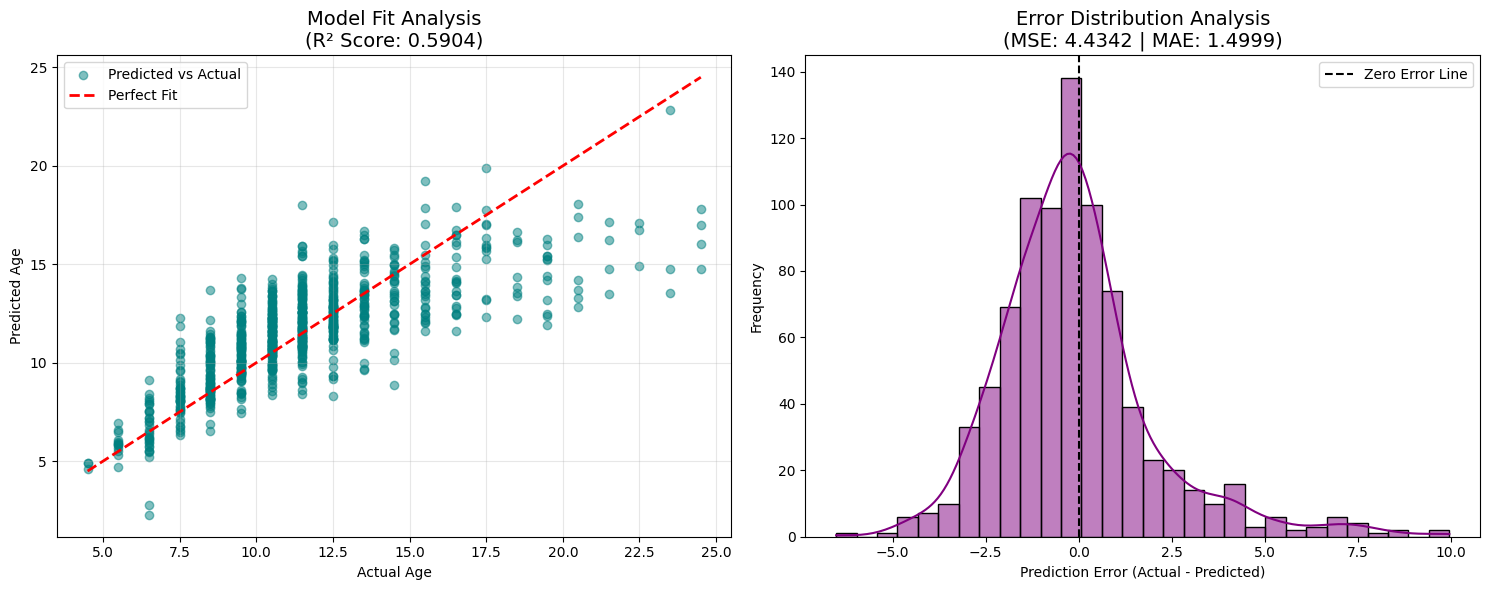

In [17]:
plt.figure(figsize=(15, 6))


plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, color='teal', label='Predicted vs Actual')
line_coords = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(line_coords, line_coords, color='red', linestyle='--', linewidth=2, label='Perfect Fit')
plt.title(f'Model Fit Analysis\n(R² Score: {r2:.4f})', fontsize=14)
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.axvline(0, color='black', linestyle='--', label='Zero Error Line')
plt.title(f'Error Distribution Analysis\n(MSE: {mse:.4f} | MAE: {mae:.4f})', fontsize=14)
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

Fitted Regression Plot &  Error distribution chart